# 🌊 Baseline — **U-Net + ResNet34** (Mô hình tham chiếu / Model 1)

## Sản phẩm cuối kỳ Deep Learning — vai trò baseline trong bộ hai mô hình

Notebook này là **mô hình baseline** trong sản phẩm cuối kỳ. Vai trò của nó:
> Cài đặt một mô hình **đơn giản, sạch, không dùng bất kỳ phương pháp đề xuất nào** trong file Concept để **chỉ ra khuyết điểm** mà mô hình cuối cùng (Dual-branch EIGNet + Uncertainty Guidance) sẽ giải quyết.

### Pipeline (đúng theo sơ đồ đề tài)

```
Input (VV, VH) ──► Normalize ──► Encoder (ResNet34) ──► Segmentation Head (U-Net) ──► Loss (Dice + BCE) ──► Evaluation
```

### Điều baseline **CỐ Ý KHÔNG dùng** (để chừa chỗ cho sản phẩm cuối)

| Phương pháp đề xuất trong Concept / sản phẩm cuối | Baseline có không? |
|---|---|
| 🚫 Uncertainty Rank Map (URM) — bản đồ độ bất định | **Không** |
| 🚫 Spatial branch + SSFAM (Edge / Uncertainty guidance, EIGNet style) | **Không** |
| 🚫 Boundary supervision (edge target từ label transitions) | **Không** |
| 🚫 Quality-aware training (hand_weight=1.0, weak_weight=0.7) | **Không, dùng 1.0 đồng đều** |
| 🚫 Tversky loss với α=0.3, β=0.7 (ưu tiên recall) | **Không, dùng Dice+BCE 50/50** |
| 🚫 Dynamic positive weighting (pos_weight = neg/pos) | **Không, BCE chuẩn** |
| 🚫 Differential LR (encoder × 0.1, decoder × 1.0) | **Không, single LR** |
| 🚫 TTA (Test-Time Augmentation, 4 flips averaged) | **Không** |
| 🚫 Threshold tuning với `min_recall` constraint | **Chỉ tune đơn giản theo F1** |
| 🚫 SAR-specific augment (brightness/contrast, gauss noise) | **Chỉ flip + rot90 cơ bản** |
| 🚫 Multi-branch architecture (semantic + spatial) | **Một branch duy nhất** |

### Điều baseline **DÙNG ĐỒNG BỘ** với sản phẩm cuối (để so sánh fair)

✅ Cùng cache `.npy` (load nhanh 10–20×)  
✅ Cùng split: TEST = {Bolivia, Ghana, USA}, val = 20% còn lại, train = phần còn lại + weak  
✅ Cùng normalize: `clip(-50, 0)` → `(x+50)/50` ∈ [0, 1]  
✅ Cùng valid mask (pixel `-1` được bỏ qua trong loss & metric)  
✅ Cùng metrics: IoU, mIoU, F1, F0.5, Precision, Recall, FAR, Risk  
✅ Cùng AMP/FP16 + AdamW + CosineAnnealing  
✅ Cùng crop 256×256 khi train  

→ Hai mô hình **giống nhau toàn bộ về data pipeline**, chỉ khác **architecture + loss + training tricks**. Điều này đảm bảo phép so sánh là về **bản chất phương pháp**, không phải về data.

### Khuyết điểm dự kiến của baseline (để báo cáo)

1. **Boundary leakage** — U-Net chuẩn không có signal supervision riêng cho ranh giới → biên water-land mờ.
2. **Urban shadow false positives** — receptive field cục bộ → bóng đô thị / mái nhà tối bị nhầm thành nước.
3. **Recall thấp trên lũ phân mảnh** — Dice+BCE 50/50 không penalize FN đặc biệt → bỏ sót lũ nhỏ, kênh hẹp.
4. **Không tận dụng weak labels** — train cả 2 nguồn với cùng weight → noise từ weak labels gây nhiễu.
5. **Không có cơ chế xử lý độ bất định** — vùng mơ hồ vẫn cho prediction "tự tin sai".

Mô hình cuối cùng sẽ **giải quyết từng điểm** này thông qua các module đề xuất trong Concept.


## 1️⃣ Cài đặt & Import

In [1]:
# Bỏ comment nếu chưa cài
# !pip install -q segmentation-models-pytorch albumentations rasterio tqdm


In [2]:
import os
import gc
import csv
import json
import time
import random
import warnings
from pathlib import Path
from datetime import datetime
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import rasterio
from rasterio.errors import NotGeoreferencedWarning
warnings.filterwarnings('ignore', category=NotGeoreferencedWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset

import segmentation_models_pytorch as smp
import albumentations as A
from tqdm.auto import tqdm

print(f"PyTorch: {torch.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")
print(f"smp    : {smp.__version__}")
print(f"album  : {A.__version__}")


PyTorch: 2.7.1+cu118
CUDA   : True
GPU    : NVIDIA GeForce RTX 3070 Ti
VRAM   : 8.0 GB
smp    : 0.5.0
album  : 2.0.8


## 2️⃣ Đường dẫn dataset

Đồng bộ với `flood-h3.ipynb`. Có 2 cách:
- **Kaggle**: `kagglehub.dataset_download("robertomarinoformica/sen1floods11-dataset")`
- **Local**: trỏ trực tiếp tới thư mục đã giải nén

Chọn 1 trong 2 cell dưới đây tùy môi trường chạy.

In [3]:
# === Option A: Kaggle (giống flood-h3) ===
# import kagglehub
# BASE = kagglehub.dataset_download("robertomarinoformica/sen1floods11-dataset")

# === Option B: Local (nếu chạy máy cá nhân) ===
# Trỏ tới thư mục chứa 'HandLabeled/' và 'WeaklyLabeled/'
BASE = "data/sen1floods_local/sen1floods11/v1.1/data/flood_events"

S1_DIR   = os.path.join(BASE, "HandLabeled", "S1Hand")
LBL_DIR  = os.path.join(BASE, "HandLabeled", "LabelHand")
WEAK_S1  = os.path.join(BASE, "WeaklyLabeled", "S1Weak")
WEAK_LBL = os.path.join(BASE, "WeaklyLabeled", "S2IndexLabelWeak")

required_dirs = [S1_DIR, LBL_DIR, WEAK_S1, WEAK_LBL]
for d in required_dirs:
    if not os.path.isdir(d):
        raise FileNotFoundError(f"Không tìm thấy {d}. Hãy chỉnh lại BASE cho đúng môi trường.")

print("Hand S1   :", S1_DIR)
print("Hand label:", LBL_DIR)
print("Weak S1   :", WEAK_S1)
print("Weak label:", WEAK_LBL)


Hand S1   : data/sen1floods_local/sen1floods11/v1.1/data/flood_events\HandLabeled\S1Hand
Hand label: data/sen1floods_local/sen1floods11/v1.1/data/flood_events\HandLabeled\LabelHand
Weak S1   : data/sen1floods_local/sen1floods11/v1.1/data/flood_events\WeaklyLabeled\S1Weak
Weak label: data/sen1floods_local/sen1floods11/v1.1/data/flood_events\WeaklyLabeled\S2IndexLabelWeak


## 3️⃣ Kiểm tra số file

In [4]:
hand_s1_files  = sorted(f for f in os.listdir(S1_DIR)  if f.endswith("_S1Hand.tif"))
hand_lbl_files = sorted(f for f in os.listdir(LBL_DIR) if f.endswith("_LabelHand.tif"))
weak_s1_files  = sorted(f for f in os.listdir(WEAK_S1)  if f.endswith("_S1Weak.tif"))
weak_lbl_files = sorted(f for f in os.listdir(WEAK_LBL) if f.endswith("_S2IndexLabelWeak.tif"))

print(f"Hand S1 files    : {len(hand_s1_files)}")
print(f"Hand label files : {len(hand_lbl_files)}")
print(f"Weak S1 files    : {len(weak_s1_files)}")
print(f"Weak label files : {len(weak_lbl_files)}")
print(f"Hand samples     : {hand_s1_files[:3]}")


Hand S1 files    : 446
Hand label files : 446
Weak S1 files    : 4384
Weak label files : 4384
Hand samples     : ['Bolivia_103757_S1Hand.tif', 'Bolivia_129334_S1Hand.tif', 'Bolivia_195474_S1Hand.tif']


## 4️⃣ Chia tập (ĐỒNG BỘ với sản phẩm cuối)

**Quan trọng**: dùng **đúng** logic split như flood-h3 để 2 mô hình evaluate trên cùng tập test.

- `TEST_GROUPS = {Bolivia, Ghana, USA}`: 3 quốc gia được giữ riêng làm test (hold-out, không leak vào train).
- Phần còn lại: 80% train, 20% val (seed=42).
- Weak labels: chỉ lấy chip thuộc các quốc gia trong train (tránh leak Bolivia/Ghana/USA).

In [5]:
def chip_name(filename, suffix):
    return filename.replace(suffix, "")

def chip_group(name):
    return name.split("_")[0]

hand_chips     = [chip_name(f, "_S1Hand.tif") for f in hand_s1_files]
weak_chips_all = [chip_name(f, "_S1Weak.tif") for f in weak_s1_files]

# Split đúng giống flood-h3 để fair comparison
TEST_GROUPS = {'Bolivia', 'Ghana', 'USA'}
test_chips  = sorted(c for c in hand_chips if chip_group(c) in TEST_GROUPS)

non_test = [c for c in hand_chips if chip_group(c) not in TEST_GROUPS]
random.seed(42)
random.shuffle(non_test)
n_val       = int(len(non_test) * 0.2)
val_chips   = non_test[:n_val]
train_chips = non_test[n_val:]

weak_train = [c for c in weak_chips_all if chip_group(c) not in TEST_GROUPS]

print(f"Test      : {len(test_chips)} chip")
print(f"Val       : {len(val_chips)} chip")
print(f"Train hand: {len(train_chips)} chip")
print(f"Train weak: {len(weak_train)} chip")
print(f"Train tổng: {len(train_chips) + len(weak_train)} chip")


Test      : 137 chip
Val       : 61 chip
Train hand: 248 chip
Train weak: 3493 chip
Train tổng: 3741 chip


## 5️⃣ Cache TIF → NPY (chạy 1 lần)

Đồng bộ với flood-h3. Cache được share giữa baseline và sản phẩm cuối — chỉ cần chạy 1 lần.

In [6]:
# Thư mục cache: dùng chung với flood-h3 (đỡ phải convert 2 lần)
CACHE = '/kaggle/working/cache' if os.path.isdir('/kaggle/working') else 'cache'
for d in ['s1_hand','lbl_hand','s1_weak','lbl_weak']:
    os.makedirs(f'{CACHE}/{d}', exist_ok=True)

print(f"Cache dir: {CACHE}")

print("\nConverting HandLabeled...")
for chip in tqdm(os.listdir(S1_DIR), desc='Hand'):
    name = chip.replace('_S1Hand.tif', '')
    npy_s1  = f'{CACHE}/s1_hand/{name}.npy'
    npy_lbl = f'{CACHE}/lbl_hand/{name}.npy'
    if not os.path.exists(npy_s1):
        with rasterio.open(f'{S1_DIR}/{chip}') as f:
            np.save(npy_s1, f.read().astype(np.float32))
    if not os.path.exists(npy_lbl):
        with rasterio.open(f'{LBL_DIR}/{name}_LabelHand.tif') as f:
            np.save(npy_lbl, f.read(1).astype(np.int16))

print("Converting WeaklyLabeled...")
for chip in tqdm(os.listdir(WEAK_S1), desc='Weak'):
    name = chip.replace('_S1Weak.tif', '')
    npy_s1  = f'{CACHE}/s1_weak/{name}.npy'
    npy_lbl = f'{CACHE}/lbl_weak/{name}.npy'
    if not os.path.exists(npy_s1):
        with rasterio.open(f'{WEAK_S1}/{chip}') as f:
            np.save(npy_s1, f.read().astype(np.float32))
    if not os.path.exists(npy_lbl):
        with rasterio.open(f'{WEAK_LBL}/{name}_S2IndexLabelWeak.tif') as f:
            np.save(npy_lbl, f.read(1).astype(np.int16))

print("Cache done!")


Cache dir: cache

Converting HandLabeled...


Hand:   0%|          | 0/446 [00:00<?, ?it/s]

Converting WeaklyLabeled...


Weak:   0%|          | 0/4384 [00:00<?, ?it/s]

Cache done!


## 6️⃣ Visualize dataset (đồng bộ flood-h3)

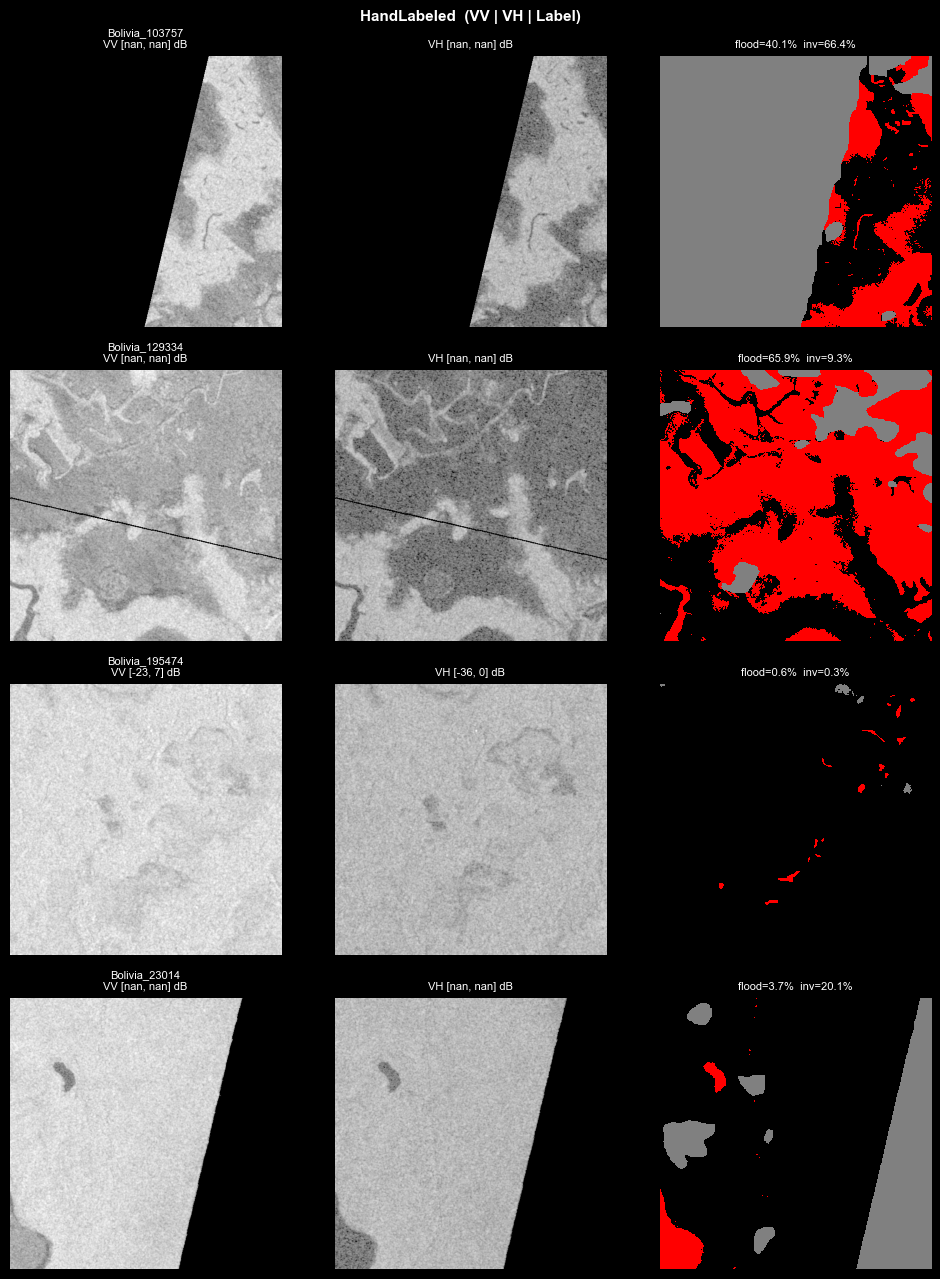

Legend: grey=invalid(-1)  black=background(0)  red=flood(1)


In [7]:
lbl_cmap = ListedColormap(['gray', 'black', 'red'])  # 0=invalid, 1=bg, 2=flood

def show_chip(ax_vv, ax_vh, ax_lbl, name, s1_dir, lbl_dir, title=''):
    s1  = np.load(f'{s1_dir}/{name}.npy')
    lbl = np.load(f'{lbl_dir}/{name}.npy')
    vv = s1[0]; vh = s1[1]
    vv_disp = (np.clip(vv, -50, 0) + 50) / 50
    vh_disp = (np.clip(vh, -50, 0) + 50) / 50

    ax_vv.imshow(vv_disp, cmap='gray', vmin=0, vmax=1)
    ax_vv.set_title(title + '\nVV [%.0f, %.0f] dB' % (vv.min(), vv.max()), fontsize=8)
    ax_vv.axis('off')

    ax_vh.imshow(vh_disp, cmap='gray', vmin=0, vmax=1)
    ax_vh.set_title('VH [%.0f, %.0f] dB' % (vh.min(), vh.max()), fontsize=8)
    ax_vh.axis('off')

    lbl_shifted = lbl.astype(np.int16) + 1
    ax_lbl.imshow(lbl_shifted, cmap=lbl_cmap, vmin=0, vmax=2, interpolation='nearest')
    flood_pct = 100 * (lbl == 1).sum() / max((lbl != -1).sum(), 1)
    inv_pct   = 100 * (lbl == -1).sum() / lbl.size
    ax_lbl.set_title('flood=%.1f%%  inv=%.1f%%' % (flood_pct, inv_pct), fontsize=8)
    ax_lbl.axis('off')

# 4 HandLabeled chips
hand_files = sorted(os.listdir(f'{CACHE}/s1_hand'))[:4]
fig, axes = plt.subplots(4, 3, figsize=(10, 13))
fig.suptitle('HandLabeled  (VV | VH | Label)', fontsize=11, fontweight='bold')
for i, fname in enumerate(hand_files):
    name = fname.replace('.npy', '')
    show_chip(axes[i,0], axes[i,1], axes[i,2],
              name, f'{CACHE}/s1_hand', f'{CACHE}/lbl_hand', title=name)
plt.tight_layout(); plt.show()

print('Legend: grey=invalid(-1)  black=background(0)  red=flood(1)')


## 7️⃣ Config baseline (ĐƠN GIẢN — không có trick nâng cao)

So với `flood-h3.ipynb`:
- **`hand_weight = weak_weight = 1.0`** — không quality-aware
- **Không có** `tversky_alpha`, `tversky_beta`, `pos_weight_cap`, `threshold_min_recall`
- **`bce_weight=0.5`, `dice_weight=0.5`** — chuẩn Dice+BCE 50/50
- **`pred_threshold=0.5`** — cố định, không tune phức tạp

In [8]:
CFG = {
    # --- Data ---
    'crop_size'    : 256,             # đồng bộ flood-h3
    'batch_size'   : 16,              # đồng bộ flood-h3
    'num_workers'  : 2,
    
    # --- Training ---
    'lr'           : 1e-4,
    'weight_decay' : 1e-4,
    'epochs'       : 50,
    'early_stop'   : 10,
    'grad_clip'    : 1.0,
    
    # --- Loss BASELINE (đơn giản, 50/50) ---
    'bce_weight'   : 0.5,             # ⭐ chuẩn 50/50, không phải 0.3 như flood-h3
    'dice_weight'  : 0.5,             # ⭐ Dice thuần, không phải Tversky
    
    # --- Sample weighting BASELINE (đồng đều, không quality-aware) ---
    'hand_weight'  : 1.0,             # ⭐ Cả Hand và Weak đều = 1.0
    'weak_weight'  : 1.0,             # ⭐ KHÔNG ưu tiên Hand như flood-h3 (0.7)
    
    # --- Threshold (cố định) ---
    'pred_threshold': 0.5,            # ⭐ đơn giản, không tune phức tạp
    
    # --- Paths ---
    'checkpoint'   : 'best_baseline_unet.pth',
    'device'       : 'cuda' if torch.cuda.is_available() else 'cpu',
    'output_dir'   : 'outputs_baseline_unet',
}

# Tạo folder output
Path(CFG['output_dir']).mkdir(exist_ok=True, parents=True)
Path(CFG['output_dir'], 'logs').mkdir(exist_ok=True)
Path(CFG['output_dir'], 'figures').mkdir(exist_ok=True)
Path(CFG['output_dir'], 'checkpoints').mkdir(exist_ok=True)

# Fix seed
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
set_seed(42)

print("Device:", CFG["device"])
print("Output:", CFG['output_dir'])


Device: cuda
Output: outputs_baseline_unet


## 8️⃣ Dataset class (đồng bộ flood-h3)

Class này **giống hệt** flood-h3 (vì preprocessing không phải "phương pháp đề xuất", chỉ là chuẩn hóa data thông thường).

Khác biệt duy nhất: sample weight = 1.0 cho cả Hand & Weak (do `CFG` đã set vậy).

In [9]:
class FloodDataset(Dataset):
    def __init__(self, chips, is_hand=True, transform=None):
        self.chips     = chips
        self.is_hand   = is_hand
        self.transform = transform
        self.sw        = CFG['hand_weight'] if is_hand else CFG['weak_weight']
        self.s1_dir    = f'{CACHE}/s1_hand'  if is_hand else f'{CACHE}/s1_weak'
        self.lbl_dir   = f'{CACHE}/lbl_hand' if is_hand else f'{CACHE}/lbl_weak'

    def __len__(self):
        return len(self.chips)

    def __getitem__(self, idx):
        name = self.chips[idx]
        s1   = np.load(f'{self.s1_dir}/{name}.npy').astype(np.float32)
        lbl  = np.load(f'{self.lbl_dir}/{name}.npy').astype(np.int16)

        # Normalize: clip(-50, 0) -> [0, 1]
        s1 = np.nan_to_num(s1, nan=-50.0, posinf=0.0, neginf=-50.0)
        s1 = (np.clip(s1, -50.0, 0.0) + 50.0) / 50.0
        s1 = s1.astype(np.float32)

        # Valid mask + binary label
        valid = (lbl != -1).astype(np.uint8)
        lbl   = np.clip(lbl, 0, 1).astype(np.uint8)

        # Albumentations (HWC)
        s1_hwc = s1.transpose(1, 2, 0)
        if self.transform is not None:
            out    = self.transform(image=s1_hwc, mask=lbl, valid=valid)
            s1_hwc = out['image']
            lbl    = out['mask']
            valid  = out['valid']

        s1_t    = torch.from_numpy(s1_hwc.transpose(2, 0, 1).copy()).float()
        lbl_t   = torch.from_numpy(lbl.copy()).long()
        valid_t = torch.from_numpy(valid.copy()).bool()
        return s1_t, lbl_t, valid_t, self.sw

# Test
ds_demo = FloodDataset(train_chips[:2], is_hand=True)
s1_t, lbl_t, valid_t, sw = ds_demo[0]
print(f"s1   : {tuple(s1_t.shape)} {s1_t.dtype} range=[{s1_t.min():.3f}, {s1_t.max():.3f}]")
print(f"lbl  : {tuple(lbl_t.shape)} {lbl_t.dtype} unique={torch.unique(lbl_t).tolist()}")
print(f"valid: {tuple(valid_t.shape)} {valid_t.dtype}")
print(f"sw   : {sw}  (baseline dùng 1.0 cho cả Hand và Weak)")


s1   : (2, 512, 512) torch.float32 range=[0.000, 1.000]
lbl  : (512, 512) torch.int64 unique=[0, 1]
valid: (512, 512) torch.bool
sw   : 1.0  (baseline dùng 1.0 cho cả Hand và Weak)


## 9️⃣ ⭐ Transforms baseline — **chỉ flip + rot90**

So với flood-h3:
- **CÓ**: `HorizontalFlip`, `VerticalFlip`, `RandomRotate90` — augment hình học cơ bản, an toàn cho mọi loại ảnh.
- **KHÔNG có**: `RandomBrightnessContrast`, `GaussNoise` — vì đây là **SAR-specific augment** mà paper / Concept khuyên dùng. Để baseline "đơn giản", ta cố ý không dùng.

Mục đích: cho phép mô hình cuối có thể bao gồm các augment SAR-specific như một trong những cải tiến.

In [10]:
train_tf = A.Compose([
    A.RandomCrop(CFG['crop_size'], CFG['crop_size']),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    # ⭐ KHÔNG có RandomBrightnessContrast (SAR radiometric jitter)
    # ⭐ KHÔNG có GaussNoise (speckle simulation)
], additional_targets={'valid': 'mask'})

val_tf = A.Compose([
    A.CenterCrop(CFG['crop_size'], CFG['crop_size']),
], additional_targets={'valid': 'mask'})

print("Train aug:")
for t in train_tf.transforms:
    print(f"  - {t.__class__.__name__}(p={t.p})")
print("Val aug: CenterCrop only")


Train aug:
  - RandomCrop(p=1.0)
  - HorizontalFlip(p=0.5)
  - VerticalFlip(p=0.5)
  - RandomRotate90(p=0.5)
Val aug: CenterCrop only


## 🔟 DataLoaders

Train data = Hand + Weak (cùng pool). Vì `sw = 1.0` cho cả 2 nên không có "quality-aware".

In [11]:
ds_hand = FloodDataset(train_chips, is_hand=True,  transform=train_tf)
ds_weak = FloodDataset(weak_train,   is_hand=False, transform=train_tf)
ds_val  = FloodDataset(val_chips,    is_hand=True,  transform=val_tf)
ds_test = FloodDataset(test_chips,   is_hand=True,  transform=val_tf)

nw = CFG['num_workers'] if os.name != 'nt' else 0
train_loader = DataLoader(
    ConcatDataset([ds_hand, ds_weak]),
    batch_size=CFG['batch_size'], shuffle=True,
    num_workers=nw, pin_memory=False, drop_last=True,
)
val_loader   = DataLoader(ds_val,  batch_size=CFG['batch_size'], shuffle=False, num_workers=nw)
test_loader  = DataLoader(ds_test, batch_size=CFG['batch_size'], shuffle=False, num_workers=nw)

print(f"Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")


Train batches: 233, Val: 4, Test: 9


## 1️⃣1️⃣ ⭐ Model — **U-Net + ResNet34 thuần**

Theo đúng pipeline ảnh: `Encoder (ResNet34)` + `Segmentation Head (U-Net)`.

**Một branch duy nhất.** Không có:
- ❌ Spatial branch (cho edge / uncertainty)
- ❌ SSFAM (Spatial-Semantic Feature Aggregation)
- ❌ Compute URM (Uncertainty Rank Map)
- ❌ Boundary supervision

So với flood-h3 dùng `smp.MAnet + ResNet18 + SpatialBranch + SSFAM`, baseline gọn hơn và đơn giản hơn rất nhiều — đó chính là điểm để mô hình cuối "vượt mặt".

In [12]:
model = smp.Unet(
    encoder_name    = 'resnet34',         # ⭐ encoder ResNet34 (theo pipeline ảnh)
    encoder_weights = 'imagenet',
    in_channels     = 2,                  # VV, VH
    classes         = 1,                  # binary segmentation
    activation      = None,               # raw logits
).to(CFG['device'])

total_params = sum(p.numel() for p in model.parameters())
print(f"Architecture: U-Net + ResNet34")
print(f"Parameters  : {total_params/1e6:.1f}M")

# Smoke test
with torch.no_grad():
    dummy = torch.randn(2, 2, CFG['crop_size'], CFG['crop_size']).to(CFG['device'])
    out = model(dummy)
print(f"Input {tuple(dummy.shape)} -> Output {tuple(out.shape)}")
del dummy, out; torch.cuda.empty_cache()


Architecture: U-Net + ResNet34
Parameters  : 24.4M
Input (2, 2, 256, 256) -> Output (2, 1, 256, 256)


## 1️⃣2️⃣ ⭐ Loss — **Dice + BCE chuẩn 50/50** (đơn giản nhất)

$$\mathcal{L} = 0.5 \cdot \mathcal{L}_{\text{BCE-valid}} + 0.5 \cdot \mathcal{L}_{\text{Dice-valid}}$$

So với flood-h3:
- flood-h3 dùng **BCE 0.3 + Tversky 0.7** với `α=0.3, β=0.7` (Tversky penalize FN gấp đôi FP để tăng recall).
- flood-h3 còn có **dynamic positive weighting** (`pos_weight = neg/pos`, capped 8.0).

Baseline **không có** các trick này → recall thường thấp hơn (model "thận trọng", thiên về dự đoán background). Đây chính là **một khuyết điểm cố ý** để mô hình cuối giải quyết.

In [13]:
class CombinedLoss(nn.Module):
    '''Baseline: Dice + BCE 50/50, mask invalid, sample weight đồng đều.'''
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, logits, labels, valid, sample_weight=1.0):
        logits_sq = logits.squeeze(1)
        valid_f   = valid.float()
        labels_f  = labels.float()

        # ---- BCE chỉ trên valid pixels ----
        bce_map = self.bce(logits_sq, labels_f)
        per_sample_bce = (bce_map * valid_f).flatten(1).sum(1) / (valid_f.flatten(1).sum(1) + 1e-6)

        # ---- Dice chuẩn (không phải Tversky α≠β) ----
        probs = torch.sigmoid(logits_sq)
        dims = (1, 2)
        intersection = (probs * labels_f * valid_f).sum(dims)
        denominator  = ((probs + labels_f) * valid_f).sum(dims)
        per_sample_dice = 1.0 - (2.0 * intersection + 1e-6) / (denominator + 1e-6)

        per_sample_loss = (
            CFG['bce_weight'] * per_sample_bce +
            CFG['dice_weight'] * per_sample_dice
        )

        # Sample weight (mặc định đều = 1.0)
        weights = torch.as_tensor(sample_weight, device=logits.device, dtype=per_sample_loss.dtype)
        if weights.ndim == 0:
            weights = weights.expand_as(per_sample_loss)
        return (per_sample_loss * weights).sum() / (weights.sum() + 1e-6)

criterion = CombinedLoss()
print("Loss: 0.5*BCE + 0.5*Dice (chuẩn, không Tversky, không dynamic positive weighting)")


Loss: 0.5*BCE + 0.5*Dice (chuẩn, không Tversky, không dynamic positive weighting)


## 1️⃣3️⃣ Metrics (đồng bộ flood-h3)

Để 2 mô hình so sánh được, ta dùng **bộ metric giống hệt** flood-h3: IoU, mIoU, F1, F0.5, Precision, Recall, FAR, Risk.

In [14]:
def metric_counts(logits, labels, valid, threshold=None):
    if threshold is None:
        threshold = CFG.get('pred_threshold', 0.5)
    preds = (torch.sigmoid(logits.squeeze(1)) > threshold).long()
    p = preds[valid]
    t = labels[valid]
    return {
        'TP': ((p==1)&(t==1)).sum().detach().cpu(),
        'FP': ((p==1)&(t==0)).sum().detach().cpu(),
        'FN': ((p==0)&(t==1)).sum().detach().cpu(),
        'TN': ((p==0)&(t==0)).sum().detach().cpu(),
    }

def metrics_from_counts(counts):
    TP = counts['TP'].float(); FP = counts['FP'].float()
    FN = counts['FN'].float(); TN = counts['TN'].float()
    eps = 1e-6
    precision = TP / (TP + FP + eps)
    recall    = TP / (TP + FN + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)
    f05       = 1.25 * precision * recall / (0.25 * precision + recall + eps)
    iou_flood = TP / (TP + FP + FN + eps)
    iou_bg    = TN / (TN + FP + FN + eps)
    miou      = (iou_flood + iou_bg) / 2
    far       = FP / (FP + TN + eps)
    risk      = 2 * FP + FN
    return {
        'iou_flood': iou_flood.item(), 'iou_bg': iou_bg.item(),
        'miou': miou.item(), 'f1': f1.item(), 'f05': f05.item(),
        'precision': precision.item(), 'recall': recall.item(),
        'far': far.item(), 'risk': risk.item(),
    }

def evaluate_loader(loader, threshold=None):
    model.eval()
    counts = {k: torch.tensor(0, dtype=torch.long) for k in ['TP','FP','FN','TN']}
    with torch.no_grad():
        for s1, lbl, valid, _ in tqdm(loader, leave=False, desc='eval'):
            s1 = s1.to(CFG['device']); lbl = lbl.to(CFG['device']); valid = valid.to(CFG['device'])
            with torch.amp.autocast('cuda', enabled=CFG['device'].startswith('cuda')):
                logits = model(s1)
            bc = metric_counts(logits.float(), lbl, valid, threshold=threshold)
            for k in counts: counts[k] += bc[k]
    return metrics_from_counts(counts)

print("Metric utilities ready.")


Metric utilities ready.


## 1️⃣4️⃣ Logger CSV + Checkpoint

In [15]:
LOG_CSV  = Path(CFG['output_dir']) / 'logs' / 'training_log.csv'
LOG_TXT  = Path(CFG['output_dir']) / 'logs' / 'training_log.txt'
CKPT_DIR = Path(CFG['output_dir']) / 'checkpoints'
BEST_CKPT = CKPT_DIR / 'best.pth'
LAST_CKPT = CKPT_DIR / 'last.pth'

LOG_FIELDS = ['epoch', 'train_loss', 'val_loss', 'val_iou', 'val_miou',
              'val_f1', 'val_precision', 'val_recall', 'val_far', 'lr', 'time_sec']

def init_csv_log():
    if not LOG_CSV.exists():
        with open(LOG_CSV, 'w', newline='', encoding='utf-8') as f:
            csv.DictWriter(f, fieldnames=LOG_FIELDS).writeheader()

def append_csv_log(row):
    with open(LOG_CSV, 'a', newline='', encoding='utf-8') as f:
        csv.DictWriter(f, fieldnames=LOG_FIELDS).writerow(row)

def append_txt_log(msg):
    with open(LOG_TXT, 'a', encoding='utf-8') as f:
        f.write(msg + '\n')

init_csv_log()
print("Log CSV:", LOG_CSV)


Log CSV: outputs_baseline_unet\logs\training_log.csv


## 1️⃣5️⃣ ⭐ Optimizer — **single LR cho toàn bộ network**

So với flood-h3 có **differential LR** (encoder ×0.1, decoder ×1.0), baseline dùng **single LR** cho tất cả param. Đây là setup mặc định, đơn giản nhất.

→ Trong báo cáo có thể nêu: differential LR là một trong những trick mà mô hình cuối áp dụng để fine-tune pretrained encoder không phá feature pretrained.

In [16]:
optimizer = torch.optim.AdamW(
    model.parameters(),                  # ⭐ tất cả params cùng 1 LR
    lr=CFG['lr'],
    weight_decay=CFG['weight_decay'],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'], eta_min=1e-6,
)
scaler = torch.amp.GradScaler('cuda')

print(f"Optimizer: AdamW (single LR = {CFG['lr']})")
print(f"Scheduler: CosineAnnealingLR (T_max={CFG['epochs']})")


Optimizer: AdamW (single LR = 0.0001)
Scheduler: CosineAnnealingLR (T_max=50)


## 1️⃣6️⃣ Training loop

**Đơn giản hóa** so với flood-h3:
- ❌ Không có TTA logic
- ❌ Không có dual-loss (`refined + 0.3*spatial`)
- ❌ Không có `nan_to_num` phức tạp cho logits
- ✅ Vẫn có resume, AMP, gradient clipping, early stopping

In [17]:
def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss = 0.0
    counts = {k: torch.tensor(0, dtype=torch.long) for k in ['TP','FP','FN','TN']}
    n = 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for s1, lbl, valid, sw in tqdm(loader, leave=False, desc='train' if training else 'val'):
            s1    = s1.to(CFG['device'], non_blocking=True)
            lbl   = lbl.to(CFG['device'], non_blocking=True)
            valid = valid.to(CFG['device'], non_blocking=True)
            sw    = sw.to(CFG['device'], non_blocking=True).float()

            amp_en = CFG['device'].startswith('cuda')
            with torch.amp.autocast('cuda', enabled=amp_en):
                logits = model(s1)
                loss   = criterion(logits, lbl, valid, sw)

            if not torch.isfinite(loss):
                if training:
                    optimizer.zero_grad(set_to_none=True)
                continue

            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
                scaler.step(optimizer); scaler.update()

            total_loss += loss.item()
            if not training:
                bc = metric_counts(logits.detach().float(), lbl, valid, threshold=CFG['pred_threshold'])
                for k in counts: counts[k] += bc[k]
            n += 1

    return total_loss / max(n, 1), (metrics_from_counts(counts) if not training else {})


def save_ckpt(epoch, val_iou, patience, is_best):
    state = {
        'epoch': epoch, 'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'scaler': scaler.state_dict(),
        'val_iou': val_iou, 'patience': patience,
    }
    torch.save(state, LAST_CKPT)
    if is_best:
        torch.save(state, BEST_CKPT)


def load_last_if_exists():
    if not LAST_CKPT.exists():
        return 1, 0.0, 0
    ckpt = torch.load(LAST_CKPT, map_location=CFG['device'])
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    if 'scaler' in ckpt: scaler.load_state_dict(ckpt['scaler'])
    print(f">>> Resume từ epoch {ckpt['epoch']+1}, best val IoU = {ckpt['val_iou']:.4f}")
    return ckpt['epoch'] + 1, ckpt['val_iou'], ckpt.get('patience', 0)


def train_baseline():
    start_epoch, best_iou, patience = load_last_if_exists()
    if start_epoch == 1:
        append_txt_log(f"==== Baseline training start — {datetime.now().isoformat()} ====")
        append_txt_log(json.dumps({k: v for k, v in CFG.items()}, indent=2))

    for epoch in range(start_epoch, CFG['epochs'] + 1):
        gc.collect(); torch.cuda.empty_cache()
        t0 = time.time()
        train_loss, _    = run_epoch(train_loader, training=True)
        val_loss,   val_m = run_epoch(val_loader,   training=False)
        scheduler.step()
        elapsed = time.time() - t0
        lr_now = optimizer.param_groups[0]['lr']

        val_iou = val_m['iou_flood']
        row = {
            'epoch': epoch,
            'train_loss': round(train_loss, 5),
            'val_loss':   round(val_loss, 5),
            'val_iou':    round(val_m['iou_flood'], 5),
            'val_miou':   round(val_m['miou'], 5),
            'val_f1':     round(val_m['f1'], 5),
            'val_precision': round(val_m['precision'], 5),
            'val_recall':    round(val_m['recall'], 5),
            'val_far':       round(val_m['far'], 5),
            'lr': round(lr_now, 6),
            'time_sec': round(elapsed, 1),
        }
        append_csv_log(row)
        msg = (f"Epoch {epoch:02d}/{CFG['epochs']} | "
               f"loss {train_loss:.4f}/{val_loss:.4f} | "
               f"IoU {val_iou:.4f} mIoU {val_m['miou']:.4f} F1 {val_m['f1']:.4f} | "
               f"P {val_m['precision']:.4f} R {val_m['recall']:.4f} FAR {val_m['far']:.4f} | "
               f"lr {lr_now:.2e} | {elapsed:.1f}s")
        print(msg); append_txt_log(msg)

        is_best = val_iou > best_iou
        if is_best:
            best_iou = val_iou; patience = 0
        else:
            patience += 1
            print(f"  (no improvement, patience {patience}/{CFG['early_stop']})")
        save_ckpt(epoch, best_iou, patience, is_best)

        if patience >= CFG['early_stop']:
            print(f"\nEarly stopping at epoch {epoch}. Best IoU: {best_iou:.4f}")
            break

    print(f"\n>>> Baseline done. Best val IoU (flood) = {best_iou:.4f}")
    append_txt_log(f">>> Best val IoU = {best_iou:.4f}")
    return best_iou

print("train_baseline() ready.")


train_baseline() ready.


## 1️⃣7️⃣ 🚀 Chạy training baseline

**Thời gian dự kiến**: ~3–5 phút/epoch trên RTX 3070 Ti với 256×256, batch 16. Tổng ~1–2 giờ. Early stop sẽ dừng sớm nếu val không cải thiện trong 10 epoch.

In [18]:
best_iou = train_baseline()


train:   0%|          | 0/233 [00:00<?, ?it/s]

val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 01/50 | loss 0.6075/0.5223 | IoU 0.5858 mIoU 0.7546 F1 0.7388 | P 0.8562 R 0.6497 FAR 0.0193 | lr 9.99e-05 | 71.1s


train:   0%|          | 0/233 [00:00<?, ?it/s]

val:   0%|          | 0/4 [00:00<?, ?it/s]

...

val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 26/50 | loss 0.4058/0.3833 | IoU 0.7148 mIoU 0.8318 F1 0.8337 | P 0.9283 R 0.7566 FAR 0.0103 | lr 4.74e-05 | 54.6s
  (no improvement, patience 9/10)


train:   0%|          | 0/233 [00:00<?, ?it/s]

val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 27/50 | loss 0.4039/0.3719 | IoU 0.7192 mIoU 0.8341 F1 0.8367 | P 0.9196 R 0.7675 FAR 0.0119 | lr 4.43e-05 | 54.3s
  (no improvement, patience 10/10)

Early stopping at epoch 27. Best IoU: 0.7449

>>> Baseline done. Best val IoU (flood) = 0.7449


## 1️⃣8️⃣ Learning Curves

    epoch  train_loss  val_loss  val_iou  val_miou   val_f1  val_precision  \
22     23     0.40548   0.37017  0.71849   0.83360  0.83618        0.91542   
23     24     0.40656   0.37718  0.66611   0.80338  0.79960        0.92555   
24     25     0.40699   0.37023  0.74016   0.84595  0.85068        0.90369   
25     26     0.40579   0.38330  0.71482   0.83179  0.83369        0.92831   
26     27     0.40385   0.37192  0.71923   0.83414  0.83668        0.91961   

    val_recall  val_far        lr  time_sec  
22     0.76958  0.01259  0.000057      54.1  
23     0.70382  0.01002  0.000054      54.2  
24     0.80355  0.01516  0.000050      54.1  
25     0.75658  0.01035  0.000047      54.6  
26     0.76748  0.01188  0.000044      54.3  


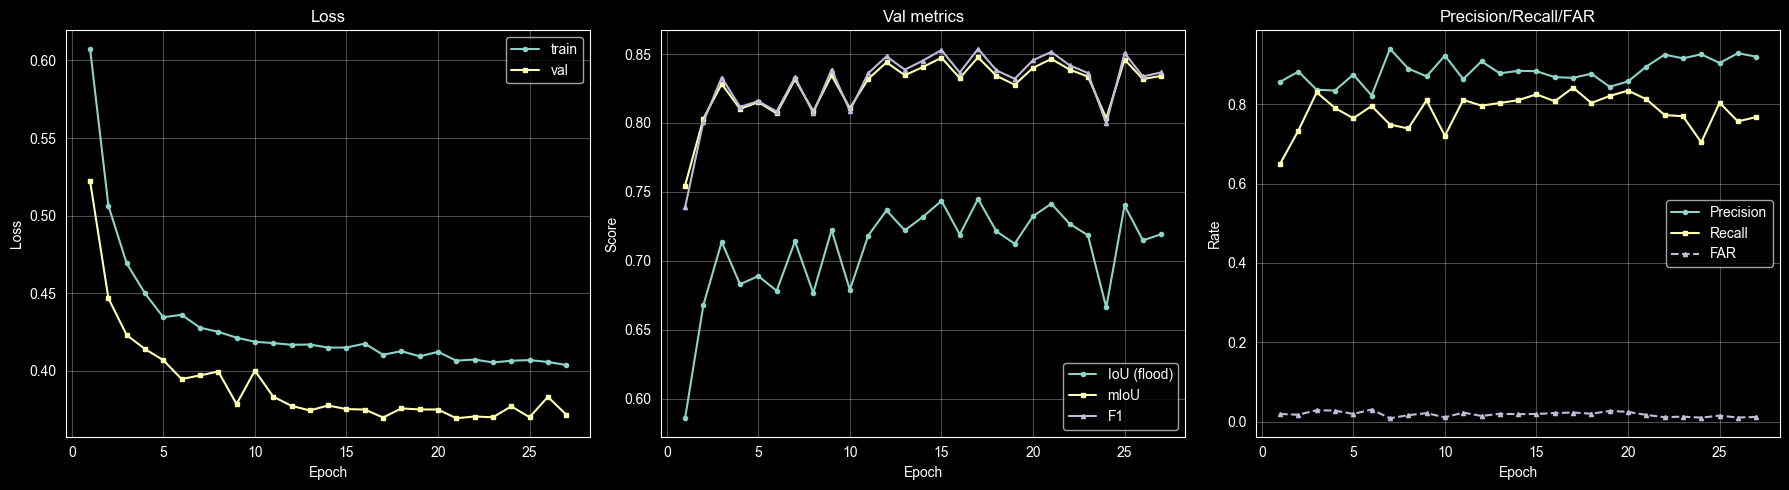

In [19]:
log_df = pd.read_csv(LOG_CSV)
print(log_df.tail(5))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(log_df['epoch'], log_df['train_loss'], label='train', marker='o', ms=3)
axes[0].plot(log_df['epoch'], log_df['val_loss'],   label='val',   marker='s', ms=3)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(log_df['epoch'], log_df['val_iou'],  label='IoU (flood)', marker='o', ms=3)
axes[1].plot(log_df['epoch'], log_df['val_miou'], label='mIoU',        marker='s', ms=3)
axes[1].plot(log_df['epoch'], log_df['val_f1'],   label='F1',          marker='^', ms=3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score'); axes[1].set_title('Val metrics')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(log_df['epoch'], log_df['val_precision'], label='Precision', marker='o', ms=3)
axes[2].plot(log_df['epoch'], log_df['val_recall'],    label='Recall',    marker='s', ms=3)
axes[2].plot(log_df['epoch'], log_df['val_far'],       label='FAR',       marker='^', ms=3, linestyle='--')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Rate'); axes[2].set_title('Precision/Recall/FAR')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(Path(CFG['output_dir']) / 'figures' / 'learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()


## 1️⃣9️⃣ Threshold tuning đơn giản (chỉ tối ưu F1)

So với flood-h3 dùng constraint `min_recall=0.82` để buộc model ưu tiên recall trước khi tối ưu F1, baseline **chỉ chọn threshold cho F1 max**, không ràng buộc khác. Đây là cách "thật thà" nhất, không can thiệp.

In [20]:
def tune_threshold_simple(loader, target='f1'):
    '''Tune threshold đơn giản: chọn theo F1 max, không có constraint.'''
    thresholds = [round(x, 2) for x in np.arange(0.20, 0.71, 0.05)]
    rows = []; best = None
    for th in thresholds:
        m = evaluate_loader(loader, threshold=th)
        row = {'threshold': th, **m}
        rows.append(row)
        if best is None or row[target] > best[target]:
            best = row
    print(' th    IoU    mIoU   F1     P      R      FAR')
    for r in rows:
        marker = '*' if r['threshold'] == best['threshold'] else ' '
        print(f"{marker}{r['threshold']:.2f}  {r['iou_flood']:.4f} {r['miou']:.4f} {r['f1']:.4f} "
              f"{r['precision']:.4f} {r['recall']:.4f} {r['far']:.4f}")
    CFG['pred_threshold'] = best['threshold']
    print(f"\nSelected threshold = {CFG['pred_threshold']:.2f} (val {target}={best[target]:.4f})")
    return best, rows

# Load best checkpoint
ckpt = torch.load(BEST_CKPT, map_location=CFG['device'])
model.load_state_dict(ckpt['model'])
print(f"Loaded best (epoch={ckpt['epoch']}, val_iou={ckpt['val_iou']:.4f})\n")

best_th, threshold_rows = tune_threshold_simple(val_loader, target='f1')

# Evaluate test
test_m = evaluate_loader(test_loader, threshold=CFG['pred_threshold'])
print(f"\n========= TEST RESULTS @ threshold {CFG['pred_threshold']:.2f} =========")
for k, v in test_m.items():
    print(f"  {k:12s}: {v:.4f}")

pd.DataFrame([test_m]).to_csv(Path(CFG['output_dir']) / 'final_results.csv', index=False)
pd.DataFrame(threshold_rows).to_csv(Path(CFG['output_dir']) / 'threshold_sweep.csv', index=False)
print("\nĐã lưu final_results.csv và threshold_sweep.csv")


Loaded best (epoch=17, val_iou=0.7449)



eval:   0%|          | 0/4 [00:00<?, ?it/s]

eval:   0%|          | 0/4 [00:00<?, ?it/s]

eval:   0%|          | 0/4 [00:00<?, ?it/s]

eval:   0%|          | 0/4 [00:00<?, ?it/s]

...

eval:   0%|          | 0/4 [00:00<?, ?it/s]

eval:   0%|          | 0/4 [00:00<?, ?it/s]

 th    IoU    mIoU   F1     P      R      FAR
 0.20  0.7213 0.8298 0.8381 0.7739 0.9139 0.0473
 0.25  0.7341 0.8386 0.8467 0.7964 0.9037 0.0409
 0.30  0.7419 0.8440 0.8519 0.8139 0.8935 0.0362
 0.35  0.7471 0.8476 0.8552 0.8289 0.8833 0.0323
*0.40  0.7493 0.8494 0.8567 0.8418 0.8721 0.0290
 0.45  0.7486 0.8494 0.8562 0.8538 0.8587 0.0260
 0.50  0.7449 0.8476 0.8538 0.8663 0.8416 0.0230
 0.55  0.7317 0.8403 0.8451 0.8789 0.8138 0.0199
 0.60  0.7046 0.8248 0.8267 0.8904 0.7715 0.0168
 0.65  0.6626 0.8006 0.7971 0.9004 0.7151 0.0140
 0.70  0.6081 0.7693 0.7563 0.9104 0.6468 0.0113

Selected threshold = 0.40 (val f1=0.8567)


eval:   0%|          | 0/9 [00:00<?, ?it/s]


========= TEST RESULTS @ threshold 0.40 =========
  iou_flood   : 0.5852
  iou_bg      : 0.9626
  miou        : 0.7739
  f1          : 0.7383
  f05         : 0.7484
  precision   : 0.7552
  recall      : 0.7222
  far         : 0.0174
  risk        : 387042.0000

Đã lưu final_results.csv và threshold_sweep.csv


## 2️⃣0️⃣ Visualize predictions + **Error Map** (làm nổi bật khuyết điểm)

Layout 6 cột: **VV | VH | Ground Truth | Prediction | Probability | Error Map**

**Error Map** là cell quan trọng nhất cho báo cáo — nó cho thấy **chính xác baseline sai ở đâu**:
- 🟩 **Xanh lá (TP)**: model đúng — phát hiện lũ
- 🟥 **Đỏ (FP)**: model **báo nhầm** — không phải lũ nhưng nói là lũ (thường là **urban shadow**, **dark roofs**)
- 🟦 **Xanh dương (FN)**: model **bỏ sót** — là lũ nhưng nói không phải (thường là **lũ phân mảnh**, **kênh hẹp**, **biên water-land**)

→ Nhìn vào error map sẽ thấy ngay 2 khuyết điểm chính: **FP nhiều ở vùng bóng đô thị** và **FN ở biên / lũ nhỏ** — đây chính là 2 mục tiêu mà sản phẩm cuối hướng tới sửa.

Showing samples: [0, 1, 5, 7]


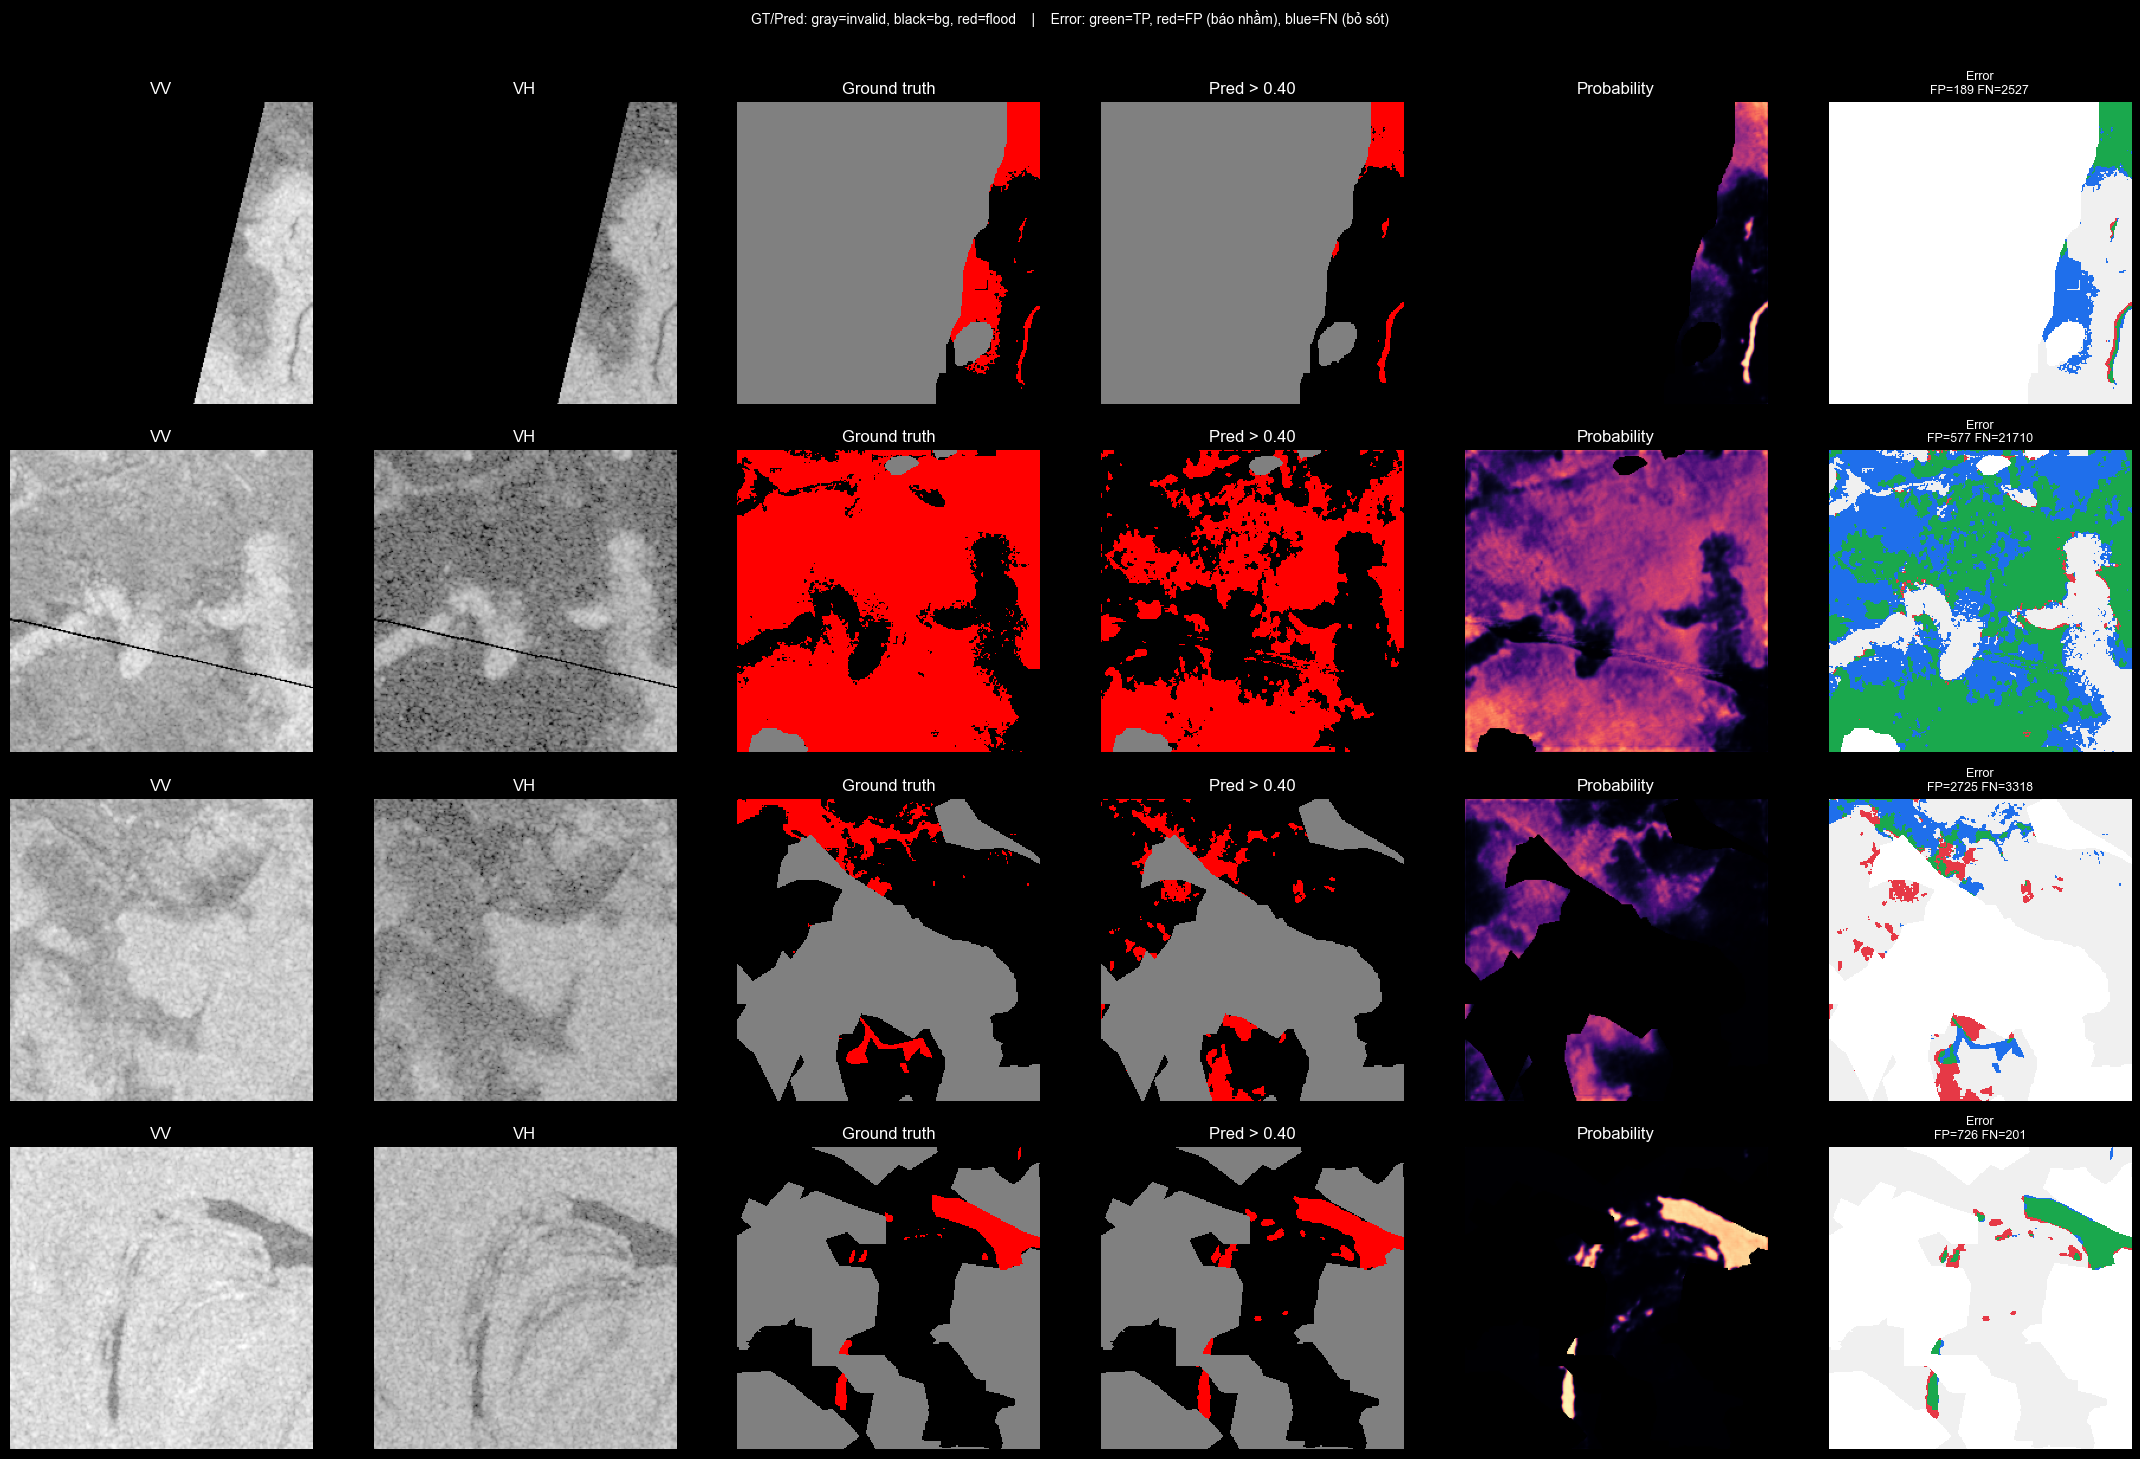

In [21]:
# Sample 4 chip test có flood (% > 5%) để show
def find_interesting_samples(dataset, n=4, min_flood_pct=0.05):
    chosen = []
    for i in range(len(dataset)):
        _, lbl, valid, _ = dataset[i]
        v = valid.numpy().astype(bool)
        if v.sum() == 0: continue
        flood_pct = (lbl.numpy()[v] == 1).mean()
        if flood_pct >= min_flood_pct:
            chosen.append(i)
        if len(chosen) >= n: break
    return chosen if chosen else list(range(min(n, len(dataset))))

sample_ids = find_interesting_samples(ds_test, n=4, min_flood_pct=0.05)
print(f"Showing samples: {sample_ids}")

# Error colormap: 0=invalid (white), 1=TN (lightgray), 2=TP (green), 3=FP (red), 4=FN (blue)
err_cmap = ListedColormap(['white', '#f0f0f0', '#1aa84d', '#e63946', '#1f6feb'])

ckpt = torch.load(BEST_CKPT, map_location=CFG['device'])
model.load_state_dict(ckpt['model']); model.eval()
PRED_THRESHOLD = CFG['pred_threshold']

fig, axes = plt.subplots(len(sample_ids), 6, figsize=(22, 3.6 * len(sample_ids)))
if len(sample_ids) == 1: axes = axes[None, :]

with torch.no_grad():
    for r, idx in enumerate(sample_ids):
        s1, lbl, valid, _ = ds_test[idx]
        s1_b = s1.unsqueeze(0).to(CFG['device'])
        with torch.amp.autocast('cuda', enabled=CFG['device'].startswith('cuda')):
            logits = model(s1_b)
        probs = torch.sigmoid(logits.squeeze().float()).cpu().numpy()
        pred  = (probs > PRED_THRESHOLD).astype(np.int32)
        gt    = lbl.numpy().astype(np.int32)
        vd    = valid.numpy().astype(bool)

        # GT / Pred shifted (+1) for colormap, invalid=0
        gt_show   = gt.copy() + 1;   gt_show[~vd]   = 0
        pred_show = pred.copy() + 1; pred_show[~vd] = 0

        # Probability with NaN for invalid
        prob_show = probs.astype(np.float32); prob_show[~vd] = np.nan

        # Error map: 0=invalid, 1=TN, 2=TP, 3=FP, 4=FN
        err = np.full(gt.shape, 0, dtype=np.int32)
        err[ vd & (gt == 0) & (pred == 0)] = 1   # TN
        err[ vd & (gt == 1) & (pred == 1)] = 2   # TP
        err[ vd & (gt == 0) & (pred == 1)] = 3   # FP (báo nhầm)
        err[ vd & (gt == 1) & (pred == 0)] = 4   # FN (bỏ sót)

        # FP/FN per-sample
        fp_count = (err == 3).sum(); fn_count = (err == 4).sum()
        tp_count = (err == 2).sum(); valid_count = vd.sum()

        axes[r, 0].imshow(s1[0].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[r, 0].set_title('VV');  axes[r, 0].axis('off')
        axes[r, 1].imshow(s1[1].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[r, 1].set_title('VH'); axes[r, 1].axis('off')
        axes[r, 2].imshow(gt_show, cmap=lbl_cmap, vmin=0, vmax=2, interpolation='nearest')
        axes[r, 2].set_title('Ground truth'); axes[r, 2].axis('off')
        axes[r, 3].imshow(pred_show, cmap=lbl_cmap, vmin=0, vmax=2, interpolation='nearest')
        axes[r, 3].set_title(f'Pred > {PRED_THRESHOLD:.2f}'); axes[r, 3].axis('off')
        axes[r, 4].imshow(prob_show, cmap='magma', vmin=0, vmax=1)
        axes[r, 4].set_title('Probability'); axes[r, 4].axis('off')
        axes[r, 5].imshow(err, cmap=err_cmap, vmin=0, vmax=4, interpolation='nearest')
        axes[r, 5].set_title(f'Error\nFP={fp_count} FN={fn_count}', fontsize=9)
        axes[r, 5].axis('off')

plt.suptitle('GT/Pred: gray=invalid, black=bg, red=flood    |    '
             'Error: green=TP, red=FP (báo nhầm), blue=FN (bỏ sót)', y=1.01, fontsize=10)
plt.tight_layout()
plt.savefig(Path(CFG['output_dir']) / 'figures' / 'predictions_with_errors.png',
            dpi=120, bbox_inches='tight')
plt.show()


## 2️⃣1️⃣ Phân tích khuyết điểm định lượng

Tính các số liệu cụ thể để báo cáo:
- **Tổng FP / FN trên test set** — số pixel bị sai mỗi loại.
- **FP rate vs FN rate** — model thiên về loại sai nào?
- **Coverage**: % flood thực được bắt được (= Recall).
- **Reliability**: khi model nói "lũ" thì đúng bao nhiêu % (= Precision).

In [22]:
# Đếm tổng FP/FN/TP/TN trên toàn test
counts_all = {k: torch.tensor(0, dtype=torch.long) for k in ['TP','FP','FN','TN']}
model.eval()
with torch.no_grad():
    for s1, lbl, valid, _ in tqdm(test_loader, desc='analysis'):
        s1 = s1.to(CFG['device']); lbl = lbl.to(CFG['device']); valid = valid.to(CFG['device'])
        with torch.amp.autocast('cuda', enabled=CFG['device'].startswith('cuda')):
            logits = model(s1)
        bc = metric_counts(logits.float(), lbl, valid, threshold=CFG['pred_threshold'])
        for k in counts_all: counts_all[k] += bc[k]

TP = counts_all['TP'].item(); FP = counts_all['FP'].item()
FN = counts_all['FN'].item(); TN = counts_all['TN'].item()
total = TP + FP + FN + TN

print(f"=" * 55)
print(f"PHÂN TÍCH KHUYẾT ĐIỂM TRÊN TEST SET")
print(f"=" * 55)
print(f"Tổng pixel valid : {total:>12,}")
print(f"  TP (đúng lũ)   : {TP:>12,}  ({100*TP/total:.2f}%)")
print(f"  TN (đúng nền)  : {TN:>12,}  ({100*TN/total:.2f}%)")
print(f"  FP (báo nhầm)  : {FP:>12,}  ({100*FP/total:.2f}%)  ← cần giảm")
print(f"  FN (bỏ sót)    : {FN:>12,}  ({100*FN/total:.2f}%)  ← cần giảm")
print()
print(f"Tỷ lệ FP / FN    : {FP/max(FN,1):.2f} : 1")
if FP > FN:
    print(f"  → Baseline THIÊN VỀ BÁO NHẦM (false positive nhiều hơn)")
    print(f"  → Khuyết điểm chính: nhầm urban shadow / dark roofs là nước")
else:
    print(f"  → Baseline THIÊN VỀ BỎ SÓT (false negative nhiều hơn)")
    print(f"  → Khuyết điểm chính: bỏ sót lũ nhỏ, kênh hẹp, biên water-land")
print()
print(f"Coverage (Recall)      : {100*TP/(TP+FN):.2f}%   "
      f"← chỉ bắt được {100*TP/(TP+FN):.0f}% lũ thật")
print(f"Reliability (Precision): {100*TP/(TP+FP):.2f}%   "
      f"← khi báo lũ, đúng {100*TP/(TP+FP):.0f}%")


analysis:   0%|          | 0/9 [00:00<?, ?it/s]

PHÂN TÍCH KHUYẾT ĐIỂM TRÊN TEST SET
Tổng pixel valid :    7,481,332
  TP (đúng lũ)   :      374,722  (5.01%)
  TN (đúng nền)  :    6,841,017  (91.44%)
  FP (báo nhầm)  :      121,449  (1.62%)  ← cần giảm
  FN (bỏ sót)    :      144,144  (1.93%)  ← cần giảm

Tỷ lệ FP / FN    : 0.84 : 1
  → Baseline THIÊN VỀ BỎ SÓT (false negative nhiều hơn)
  → Khuyết điểm chính: bỏ sót lũ nhỏ, kênh hẹp, biên water-land

Coverage (Recall)      : 72.22%   ← chỉ bắt được 72% lũ thật
Reliability (Precision): 75.52%   ← khi báo lũ, đúng 76%


## 2️⃣2️⃣ Kết luận baseline & lộ trình so sánh với sản phẩm cuối

### Khuyết điểm chính của baseline (đã định lượng ở trên + nhìn được trong error map)

| Khuyết điểm baseline | Bằng chứng | Giải pháp trong sản phẩm cuối |
|---|---|---|
| **1. Urban shadow false positive** | FP nhiều ở vùng tối có texture phức tạp | **Spatial branch** + **URM** trong SSFAM lọc nhiễu từ skip connection (theo Ý tưởng 3 trong Concept) |
| **2. Boundary leakage** (biên water-land mờ) | FN rải dày trên contour | **Boundary supervision** từ `make_boundary_target` + spatial branch chuyên học edge |
| **3. Recall thấp trên lũ phân mảnh** | FN >> TP ở vùng lũ nhỏ | **Tversky loss** với β=0.7 penalize FN nặng hơn FP |
| **4. Không tận dụng weak labels** | Cả Hand & Weak weight = 1.0 → noise weak ảnh hưởng tới Hand | **Quality-aware training** (hand=1.0, weak=0.7) — đề xuất bởi paper Remote Sensing 2026 |
| **5. Không định lượng độ bất định** | Prediction quá tự tin ở vùng mơ hồ | **URM** (Uncertainty Rank Map) + **Adapter** điều biến theo độ tự tin (Ý tưởng 1 + 2 trong Concept) |
| **6. Không có data augment SAR-specific** | Không robust với speckle/calibration | **RandomBrightnessContrast + GaussNoise** mô phỏng SAR noise |
| **7. Encoder pretrained dễ bị "đẩy" lệch** | Single LR ép encoder thay đổi nhanh như decoder | **Differential LR** (encoder ×0.1) giữ feature pretrained ổn định |

### Bảng so sánh dự kiến trong báo cáo

| Phương pháp | Architecture | Loss | Weak handling | mIoU | F1 | Precision | Recall | FAR |
|---|---|---|---|---|---|---|---|---|
| **Baseline (notebook này)** | U-Net + ResNet34 | Dice+BCE 50/50 | weight 1.0 | ? | ? | ? | ? | ? |
| **Sản phẩm cuối (flood-h3)** | EIGNet + Uncertainty | BCE+Tversky+Edge | Quality-aware | ? | ? | ? | ? | ? |
| **Cải thiện** | — | — | — | **+?** | **+?** | **+?** | **+?** | **−?** |

→ Trong báo cáo, **mỗi cải tiến** của mô hình cuối phải được **chứng minh giảm khuyết điểm nào** ở bảng trên thông qua ablation và visualization.

### Files xuất ra (`outputs_baseline_unet/`)
- `checkpoints/best.pth`, `last.pth`
- `logs/training_log.csv`, `training_log.txt`
- `figures/learning_curves.png`, `predictions_with_errors.png`
- `final_results.csv`, `threshold_sweep.csv`

🎓 Baseline đã sẵn sàng để so sánh với sản phẩm cuối cùng!
